In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import sbibm

from pyro_cases.run import train_and_test

In [3]:
device = torch.device("cuda:5")

In [4]:
sbibm.get_available_tasks()

['sir',
 'two_moons',
 'slcp',
 'gaussian_linear_uniform',
 'lotka_volterra',
 'bernoulli_glm',
 'gaussian_mixture',
 'gaussian_linear',
 'slcp_distractors',
 'bernoulli_glm_raw']

In [5]:
# torch.autograd.set_detect_anomaly(True)

In [6]:
out_dict = train_and_test(task_name="arm_electric_inter",
                          seed=123456,
                          device=device,
                          lr=1e-3,
                          lr_schedule="cosine_annealing",
                          num_particles=1,
                          vectorize_particles=False,
                          batch_size=1024,
                          network_width=1024,
                          steps=10_000,
                          direct_compare_n_obs=10,
                          k_hat_n_obs=30,
                          k_hat_n_samples=100,
                          vsbc_n_obs=1000,
                          show_progress=True,
                          return_vae=True,
                          suppress_error=False)

100%|██████████| 10000/10000 [02:51<00:00, 58.16it/s]


[123456 completes] task start time: Sat Mar 29 18:43:15 2025; task end time: Sat Mar 29 18:46:24 2025; cost time: 189.2 seconds


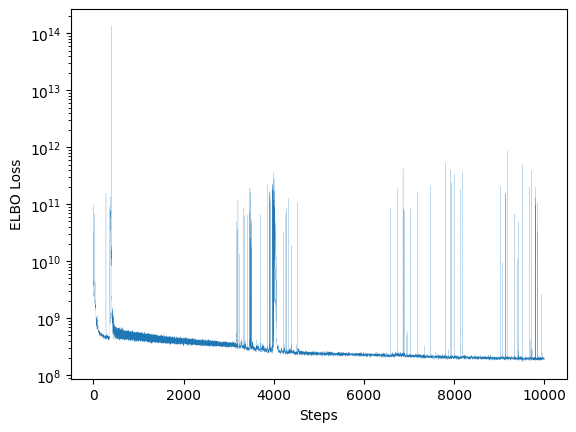

In [7]:
plt.plot(out_dict["elbo_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("ELBO Loss")
plt.yscale("log")
plt.show()

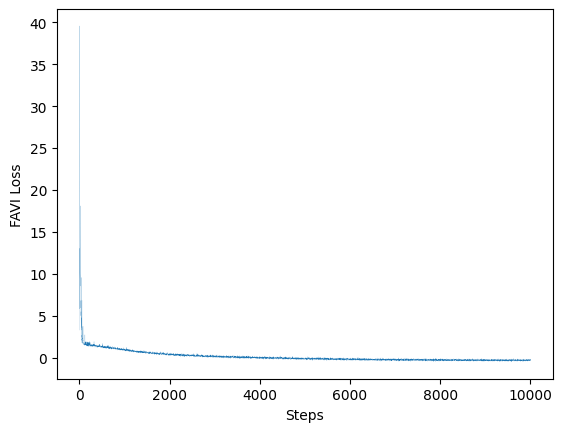

In [8]:
plt.plot(out_dict["favi_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("FAVI Loss")
# plt.yscale("log")
plt.show()

### K hat

In [9]:
print(out_dict["favi_k_hat"])
print(out_dict["elbo_k_hat"])

tensor([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf, inf, inf, inf, inf], dtype=torch.float64)
tensor([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf, inf, inf, inf, inf], dtype=torch.float64)


In [10]:
print(out_dict["favi_k_hat"].mean())
print(out_dict["elbo_k_hat"].mean())

tensor(inf, dtype=torch.float64)
tensor(inf, dtype=torch.float64)


### VSBC

In [11]:
favi_vsbc = out_dict["favi_vsbc"]
elbo_vsbc = out_dict["elbo_vsbc"]

In [12]:
def plot_vsbc(vsbc_matrix: torch.Tensor):
    theta_dim = vsbc_matrix.shape[0]
    nrows = theta_dim // 4 + 1 if theta_dim % 4 != 0 else theta_dim // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()
    for i, vsbc_samples in enumerate(vsbc_matrix):
        ax = axes[i]
        sns.kdeplot(vsbc_samples, 
                    ax=ax, 
                    clip=(0, 1),
                    fill=True,
                    bw_adjust=0.7)
        ax.axvline(x=0.5, color="red", linestyle="--")
        ax.set_title(f"theta[{i}]")
    fig.tight_layout()
    fig.show()

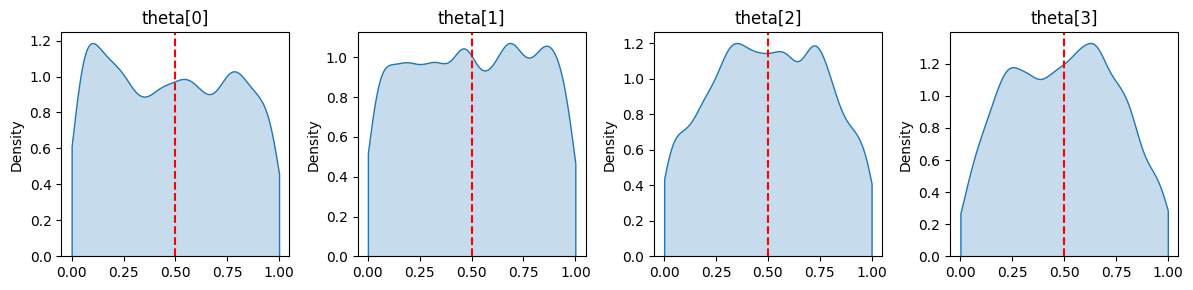

In [13]:
plot_vsbc(favi_vsbc)

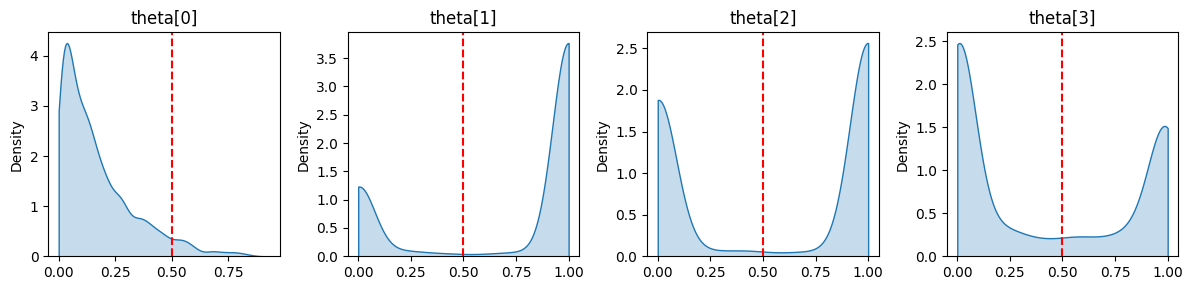

In [14]:
plot_vsbc(elbo_vsbc)

### Output

In [15]:
out_dict["elbo_test_dict_list"][0]["obs_seed"]

10000

In [16]:
out_dict["elbo_test_dict_list"][0]["obs"]

tensor([[ 7.0000e+00,  7.0000e+00,  0.0000e+00,  8.0000e+00,  4.0000e+00,
          8.0000e+00,  3.0000e+00,  2.0000e+00,  2.0000e+00,  2.0000e+00,
          0.0000e+00,  6.0000e+00,  7.0000e+00,  4.0000e+00,  4.0000e+00,
          1.0000e+00,  1.0000e+00,  5.0000e+00,  0.0000e+00,  2.0000e+00,
          9.0000e+00,  5.0000e+00,  3.0000e+00,  1.0000e+00,  4.0000e+00,
          0.0000e+00,  5.0000e+00,  5.0000e+00,  9.0000e+00,  1.0000e+00,
          7.0000e+00,  6.0000e+00,  2.0000e+00,  8.0000e+00,  2.0000e+00,
          0.0000e+00,  1.0000e+00,  6.0000e+00,  1.0000e+00,  6.0000e+00,
          0.0000e+00,  4.0000e+00,  4.0000e+00,  1.0000e+00,  7.0000e+00,
          8.0000e+00,  6.0000e+00,  6.0000e+00,  6.0000e+00,  7.0000e+00,
          2.2000e+01,  2.8000e+01,  2.2000e+01,  2.8000e+01,  2.3000e+01,
          2.4000e+01,  2.1000e+01,  2.7000e+01,  2.7000e+01,  2.3000e+01,
          2.8000e+01,  2.1000e+01,  2.6000e+01,  2.9000e+01,  2.0000e+01,
          2.4000e+01,  2.2000e+01,  2.

In [17]:
out_dict["elbo_test_dict_list"][0]["true_theta"]

tensor([ 0.4952, -0.0541, -0.2502, -0.3750])

In [18]:
out_dict["elbo_test_dict_list"][0]["est_mu"]

tensor([-2.8348, -0.0653, -0.0167, -0.4167])

In [19]:
out_dict["elbo_test_dict_list"][0]["est_sigma2"]

tensor([5.0000e+00, 5.2849e-03, 5.4370e-04, 8.6333e-04])

In [20]:
out_dict["favi_test_dict_list"][0]["obs_seed"]

10000

In [21]:
out_dict["favi_test_dict_list"][0]["obs"]

tensor([[ 7.0000e+00,  7.0000e+00,  0.0000e+00,  8.0000e+00,  4.0000e+00,
          8.0000e+00,  3.0000e+00,  2.0000e+00,  2.0000e+00,  2.0000e+00,
          0.0000e+00,  6.0000e+00,  7.0000e+00,  4.0000e+00,  4.0000e+00,
          1.0000e+00,  1.0000e+00,  5.0000e+00,  0.0000e+00,  2.0000e+00,
          9.0000e+00,  5.0000e+00,  3.0000e+00,  1.0000e+00,  4.0000e+00,
          0.0000e+00,  5.0000e+00,  5.0000e+00,  9.0000e+00,  1.0000e+00,
          7.0000e+00,  6.0000e+00,  2.0000e+00,  8.0000e+00,  2.0000e+00,
          0.0000e+00,  1.0000e+00,  6.0000e+00,  1.0000e+00,  6.0000e+00,
          0.0000e+00,  4.0000e+00,  4.0000e+00,  1.0000e+00,  7.0000e+00,
          8.0000e+00,  6.0000e+00,  6.0000e+00,  6.0000e+00,  7.0000e+00,
          2.2000e+01,  2.8000e+01,  2.2000e+01,  2.8000e+01,  2.3000e+01,
          2.4000e+01,  2.1000e+01,  2.7000e+01,  2.7000e+01,  2.3000e+01,
          2.8000e+01,  2.1000e+01,  2.6000e+01,  2.9000e+01,  2.0000e+01,
          2.4000e+01,  2.2000e+01,  2.

In [22]:
out_dict["favi_test_dict_list"][0]["true_theta"]

tensor([ 0.4952, -0.0541, -0.2502, -0.3750])

In [23]:
out_dict["favi_test_dict_list"][0]["est_mu"]

tensor([-0.0152, -0.0075, -0.2644, -0.3806])

In [24]:
out_dict["favi_test_dict_list"][0]["est_sigma2"]

tensor([0.2599, 0.2342, 0.0469, 0.0029])